In [1]:
'''
 # @ Author: Lex Albrandt
 # @ Create Time: 2026-02-17 12:05:47
 # @ Modified by: Lex Albrandt
 # @ Modified time: 2026-02-17 12:05:49
 # @ Description: This is a python file for a data exploration notebook
 '''

'\n # @ Author: Lex Albrandt\n # @ Create Time: 2026-02-17 12:05:47\n # @ Modified by: Lex Albrandt\n # @ Modified time: 2026-02-17 12:05:49\n # @ Description: This is a python file for a data exploration notebook\n '

### Sources  
- https://archive.physionet.org/physiobank/annotations.shtml  

In [2]:
# Imports
import sys
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

In [3]:
print(sys.executable)

/home/lexlexpdx/Desktop/valinor/portfolio/ecg-pvc-detection/myenv/bin/python


The first step is to load an individual record and associated annotations.  
Then isolate the only lead II

In [4]:
record_id = '100'
record = wfdb.rdrecord(f'../data/{record_id}')
annotation = wfdb.rdann(f'../data/{record_id}', 'atr')

# Get channel names
print(record.sig_name[0])

# selects the first lead, ECG -> 1d array of voltage values over time
# in this case, the first lead is the most common: Lead II
ecg_signal = record.p_signal[:,0]

MLII


Now we want to clean the ekg to remove baseline wander and high-frequency
noise. We will do this using neurokit2 functionality. The chosen filter is  
"neurokit", which uses a butterworth bandpass filter 0.5-45 Hz because it  
preserves beat morphology. This step is important to do BEFORE extracting
beats

In [5]:
# Sampling frequency
fs = record.fs
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate = fs, method = "neurokit")
num_seconds = 30
num_samples = int(num_seconds * fs)
time = np.arange(num_samples) / fs

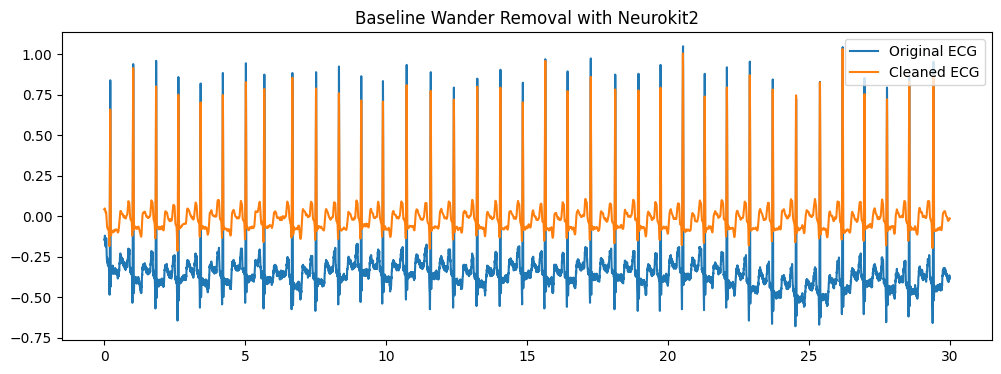

In [6]:
plt.figure(figsize = (12, 4))
plt.plot(time, ecg_signal[:num_samples], label = 'Original ECG')
plt.plot(time, ecg_cleaned[:num_samples], label = 'Cleaned ECG')
plt.legend()
plt.title('Baseline Wander Removal with Neurokit2')
plt.show()

Now we need to view annotations for each beat and see how the align
We will do this for each individual patient. We want to binarize this  
detection so that it makes for easier classification

In [7]:
PVC_SYMBOLS = ['V', 'E']
NORMAL_SYMBOLS = ['N', 'L', 'R']

# PVC = 1, Normal = 0
beat_labels = []
for symbol in annotation.symbol:
    if symbol in PVC_SYMBOLS:
        beat_labels.append(1)
    elif symbol in NORMAL_SYMBOLS:
        beat_labels.append(1)
    else:
        beat_labels.append(-1)

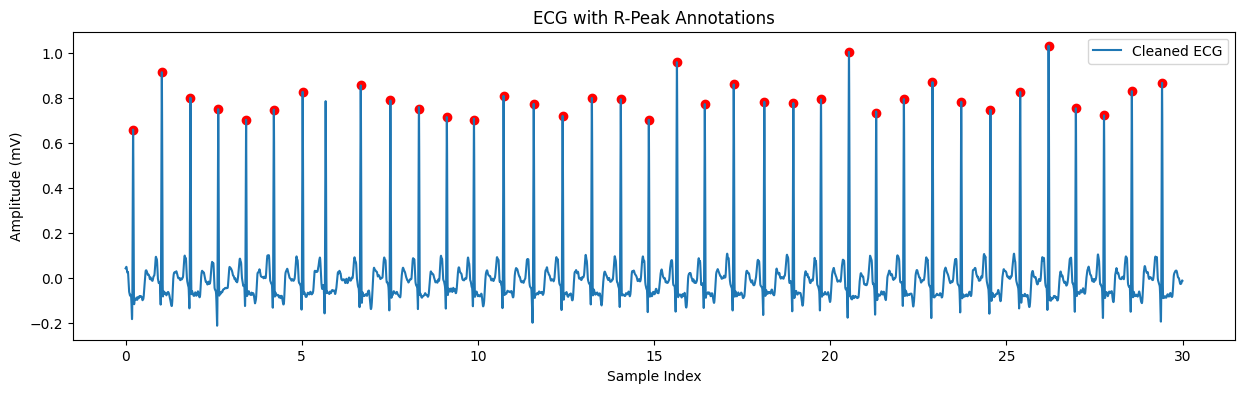

In [8]:
# Plot beats
plt.figure(figsize = (15, 4))
plt.plot(time[:num_samples], ecg_cleaned[:num_samples], label = "Cleaned ECG")

for i, r in enumerate(annotation.sample[:120]):
    # convert R-Peak index into seconds
    t = r / fs
    if t > num_seconds:
        break
    label = beat_labels[i]
    if label == 1:
        plt.scatter(t, ecg_cleaned[r], color = "red", label = "PVC" if i == 0 else "")
    if label == 0:
        plt.scatter(t, ecg_cleaned[r], color = "green", label = "Normal" if i == 0 else "")

plt.title("ECG with R-Peak Annotations")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

Another step in the journey is determining the window length for  
isolating individual peaks. So let's do that. We already cleaned the ECG  
so now let's find signals and info using the neurokit library

In [9]:
# Find Peaks
peaks = nk.ecg_findpeaks(ecg_cleaned, sampling_rate = fs)

# Info contains peak locations ['ECG_R_Peaks'] is what we want
r_peaks = peaks['ECG_R_Peaks']

# compute typical duration
rr_intervals = np.diff(r_peaks) / fs
print(f"Mean RR Interval: {rr_intervals.mean():.3f} sec")
print(f"Min RR Interval: {rr_intervals.min():.3f} sec")
print(f"Max RR Interval: {rr_intervals.max():.3f} sec")

Mean RR Interval: 0.795 sec
Min RR Interval: 0.522 sec
Max RR Interval: 1.667 sec
